In [30]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

In [36]:
train = pd.read_csv(r"train.csv")
train = train.ffill().fillna(0)

In [38]:
drop_cols = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
X_train = train.drop(columns=[c for c in drop_cols if c in train.columns])
y_train = train["forward_returns"]

In [42]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
test = pd.read_csv(r"test.csv")
test = test.ffill().fillna(0)

In [12]:
extra_cols = set(test.columns) - set(X_train.columns)
test = test.drop(columns=list(extra_cols))

In [14]:
X_test = test[X_train.columns]


In [16]:
test_preds = model.predict(X_test)


In [18]:
allocations = 1 + test_preds / test_preds.std()
allocations = allocations.clip(0, 2)

In [20]:
submission = pd.DataFrame({
    "date_id": test["date_id"],  # works if date_id exists
    "allocation": allocations
})
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created successfully!")

✅ submission.csv created successfully!


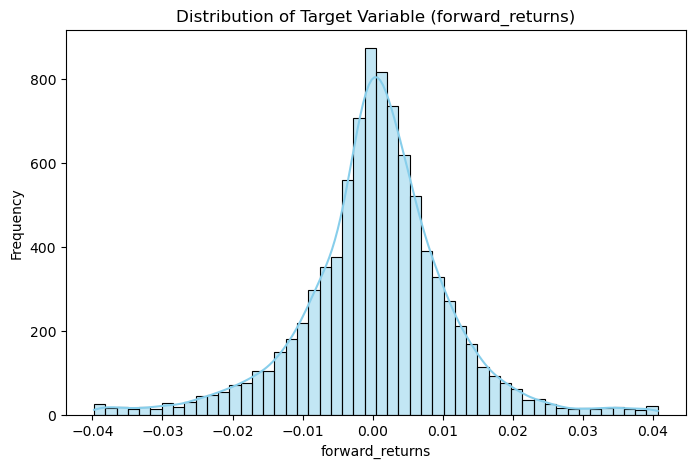

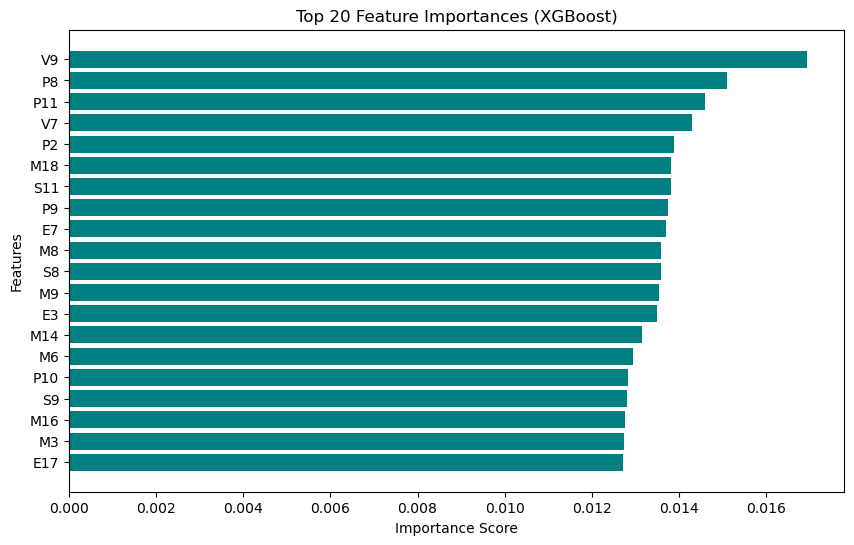

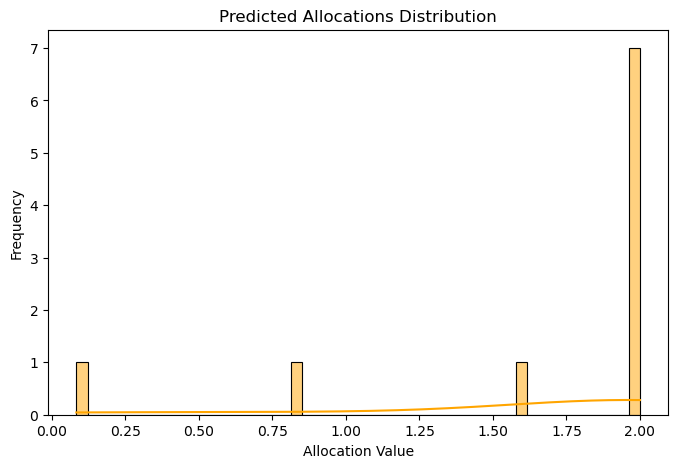

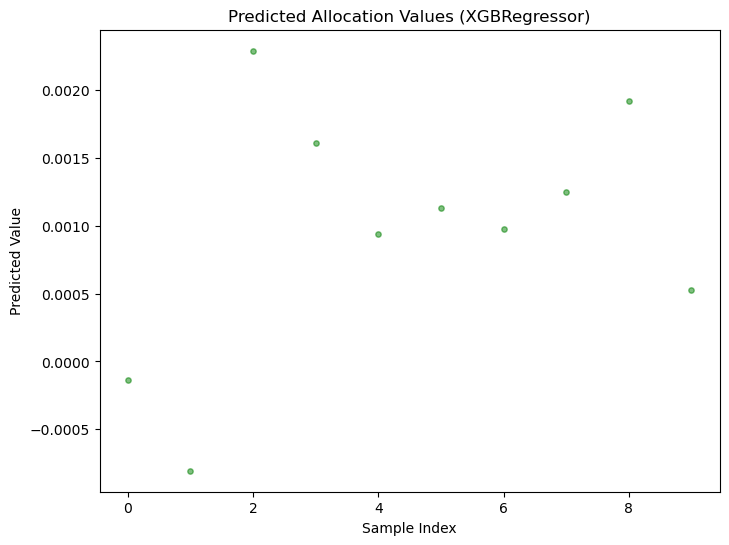

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot 1: Distribution of target variable ---
plt.figure(figsize=(8, 5))
sns.histplot(y_train, bins=50, kde=True, color='skyblue')
plt.title("Distribution of Target Variable (forward_returns)")
plt.xlabel("forward_returns")
plt.ylabel("Frequency")
plt.show()

# --- Plot 2: Feature importance from XGBoost ---
plt.figure(figsize=(10, 6))
xgb_importances = model.feature_importances_
sorted_idx = np.argsort(xgb_importances)[-20:]  # Top 20 features
plt.barh(range(len(sorted_idx)), xgb_importances[sorted_idx], color='teal')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# --- Plot 3: Predicted Allocations ---
plt.figure(figsize=(8, 5))
sns.histplot(allocations, bins=50, kde=True, color='orange')
plt.title("Predicted Allocations Distribution")
plt.xlabel("Allocation Value")
plt.ylabel("Frequency")
plt.show()

# --- Plot 4: Actual vs Predicted (optional) ---
plt.figure(figsize=(8, 6))
plt.scatter(range(len(test_preds)), test_preds, alpha=0.5, color='green', s=15)
plt.title("Predicted Allocation Values (XGBRegressor)")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Value")
plt.show()


In [24]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error

# ✅ Predict on training data (since we don't have true y_test)
y_pred_train = model.predict(X_train)

# --- Compute Metrics ---
mse = mean_squared_error(y_train, y_pred_train)
mape = mean_absolute_percentage_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

# --- Adjusted R² ---
n = X_train.shape[0]  # number of samples
p = X_train.shape[1]  # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# --- Print Results ---
print("📊 Model Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.6f}")
print(f"R-squared (R²): {r2:.6f}")
print(f"Adjusted R-squared: {adj_r2:.6f}")


📊 Model Performance Metrics:
Mean Squared Error (MSE): 0.000039
Mean Absolute Percentage Error (MAPE): 36582507481.460091
R-squared (R²): 0.644767
Adjusted R-squared: 0.640986


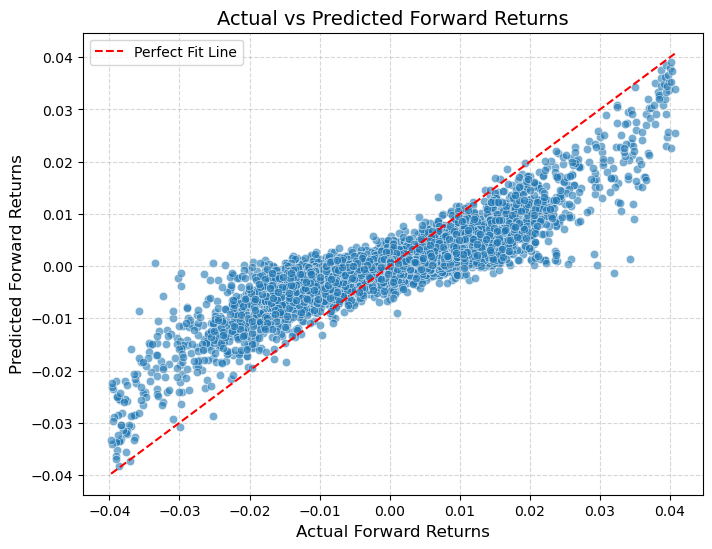

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_train, y=y_pred_train, alpha=0.6)
plt.xlabel("Actual Forward Returns", fontsize=12)
plt.ylabel("Predicted Forward Returns", fontsize=12)
plt.title("Actual vs Predicted Forward Returns", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Plot perfect prediction line
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Fit Line")

plt.legend()
plt.show()

In [28]:
pip install shap lime


Note: you may need to restart the kernel to use updated packages.


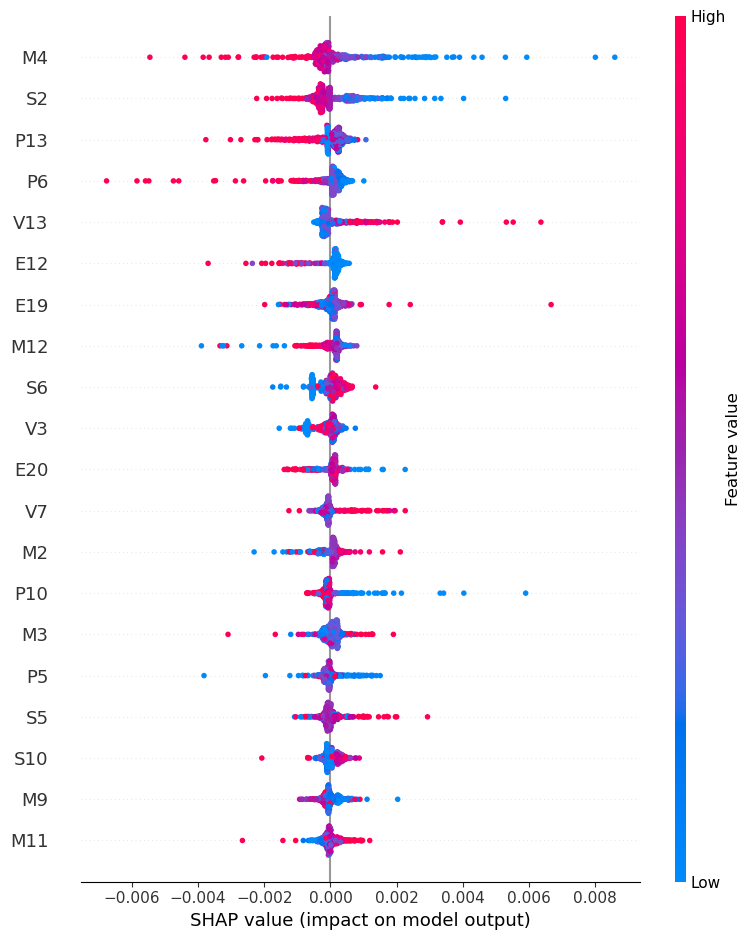

In [28]:
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np

# --- SHAP for XGBoost ---

# Use a sample of data as background for SHAP (to speed things up)
background = X_train.sample(500, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(background)

# SHAP summary plot
shap.summary_plot(shap_values, background, show=True)

# If you want to save the plot:
plt.savefig("shap_xgboost_summary.png", dpi=300, bbox_inches='tight')
plt.close()


# --- LIME for XGBoost ---

# Initialize Lime explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

# Choose a random instance from training set to explain
idx = np.random.randint(0, len(X_train))
instance = X_train.iloc[idx]

lime_exp = lime_explainer.explain_instance(
    data_row=instance.values,
    predict_fn=model.predict,
    num_features=10
)

# Show LIME explanation in notebook (or in console)
lime_exp.show_in_notebook()

# To save LIME explanation as html file
lime_exp.save_to_file("lime_xgboost_explanation.html")
